<a href="https://colab.research.google.com/github/VincentGefflaut/notMIWAE-project/blob/notebook-SVHN-reproductible/SVHN_MIWAE_notMIWAE_D100_WithoutL2Reg_KL_TrainingMissing_WithCNN_Micro_Temp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIWAE and not-MIWAE on SVHN Dataset

This notebook implements the clipping experiment from the not-MIWAE paper (Section 4.3).
We emulate a clipping phenomenon where pixel values above a threshold are set to missing.

## 1. Imports and Setup

In [1]:
import os
# os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
import tensorflow_probability as tfp
import keras
import matplotlib.pyplot as plt
import time
from scipy.io import loadmat

# Check GPU availability
if tf.test.is_gpu_available():
    print("GPU is available!")
    print(f"GPU Device: {tf.test.gpu_device_name()}")
else:
    print("GPU is NOT available, using CPU.")

plt.rcParams["font.family"] = "serif"
plt.rcParams['font.size'] = 12.0
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU is available!
GPU Device: /device:GPU:0


## 2. Load SVHN Data

In [2]:
# Download SVHN dataset if not present
import urllib.request

data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

train_url = 'http://ufldl.stanford.edu/housenumbers/train_32x32.mat'
test_url = 'http://ufldl.stanford.edu/housenumbers/test_32x32.mat'

train_path = os.path.join(data_dir, 'train_32x32.mat')
test_path = os.path.join(data_dir, 'test_32x32.mat')

if not os.path.exists(train_path):
    print("Downloading SVHN training data...")
    urllib.request.urlretrieve(train_url, train_path)
    print("Done!")

if not os.path.exists(test_path):
    print("Downloading SVHN test data...")
    urllib.request.urlretrieve(test_url, test_path)
    print("Done!")

Done!
Done!


In [3]:
# Load and preprocess data
train_data = loadmat(train_path)
test_data = loadmat(test_path)

# Extract images and convert to grayscale, normalize to [0, 1]
def preprocess_svhn(data):
    X = data['X'].astype(np.float32)
    # Transpose from (32, 32, 3, N) to (N, 32, 32, 3)
    X = np.transpose(X, (3, 0, 1, 2))
    # Convert to grayscale
    X = np.mean(X, axis=-1, keepdims=True)
    # Normalize to [0, 1]
    X = X / 255.0
    return X

X_train = preprocess_svhn(train_data)
X_test = preprocess_svhn(test_data)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# Use a subset for faster training (optional)
N_train = 10000  # Use 10k samples for training
N_test = 2000    # Use 2k samples for testing

np.random.seed(42)
train_idx = np.random.choice(len(X_train), N_train, replace=False)
test_idx = np.random.choice(len(X_test), N_test, replace=False)

X_train = X_train[train_idx]
X_test = X_test[test_idx]

print(f"Using {N_train} training samples and {N_test} test samples")

Training data shape: (73257, 32, 32, 1)
Test data shape: (26032, 32, 32, 1)
Using 10000 training samples and 2000 test samples


## 3. Introduce Missing Data (Clipping)

We use a self-masking mechanism identical to the paper:
$$P(s_{ij} = 1 | x_{ij}) = \frac{1}{1 + e^{-\text{logits}}}, \quad \text{logits} = W(x_{ij} - b)$$

where $W = -50$ and $b = 0.75$ (clipping point).

## C'est le mask ici avec W et b fixe

In [4]:
# Missing process parameters (from paper)
W_miss = -50.0
b_miss = 0.75

def introduce_missing(X, W, b):
    """Introduce MNAR missing data via clipping mechanism."""
    logits = W * (X - b)
    prob_observed = 1.0 / (1.0 + np.exp(-logits))
    S = np.random.binomial(1, prob_observed).astype(np.float32)

    # Create masked version (0 where missing)
    X_masked = X * S

    return X_masked, S

# Apply missing mechanism to training and test data
X_train_masked, S_train = introduce_missing(X_train, W_miss, b_miss)
X_test_masked, S_test = introduce_missing(X_test, W_miss, b_miss)

# Calculate missing rate
missing_rate_train = 1 - np.mean(S_train)
missing_rate_test = 1 - np.mean(S_test)
print(f"Training missing rate: {missing_rate_train:.2%}")
print(f"Test missing rate: {missing_rate_test:.2%}")

Training missing rate: 8.15%
Test missing rate: 11.31%


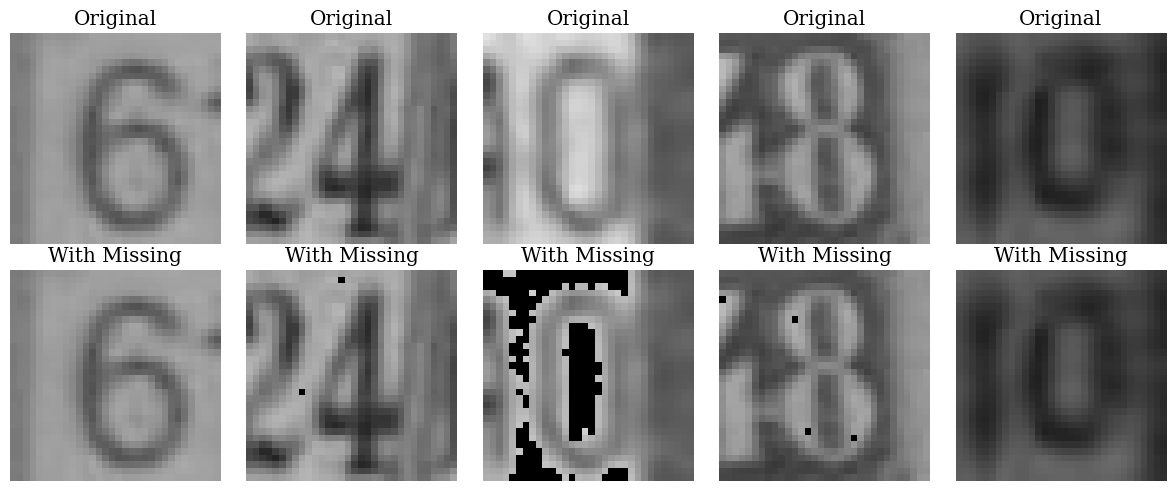

In [5]:
# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_train[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(X_train_masked[i, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('With Missing')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 4. Model Settings

In [6]:
# Model hyperparameters
n_latent = 100
n_samples = 5  # Number of importance samples (K)
batch_size = 64
max_iter = 50000  # Reduce for faster experimentation
learning_rate = 0.001

# Data dimensions
img_height, img_width, img_channels = 32, 32, 1
D = img_height * img_width * img_channels

## 5. Build the Model

We build a convolutional VAE with:
- Encoder: Conv layers -> latent distribution
- Decoder: Dense + ConvTranspose layers -> reconstructed image
- Missing model: Logistic regression per pixel (for not-MIWAE)

In [7]:
print("Building computation graph...")
tf.reset_default_graph()

# Placeholders
with tf.variable_scope('input'):
    x_pl = tf.placeholder(tf.float32, [None, img_height, img_width, img_channels], 'x_pl')
    s_pl = tf.placeholder(tf.float32, [None, img_height, img_width, img_channels], 's_pl')
    n_pl = tf.placeholder(tf.int32, shape=(), name='n_pl')
    is_training = tf.placeholder(tf.bool, shape=(), name='is_training')

Building computation graph...


In [8]:
# Encoder (Convolutional)

with tf.variable_scope('encoder'):
    #l2_reg = tf.keras.regularizers.l2(1e-4)

    # Input: [batch, 32, 32, 1]
    enc = keras.layers.Conv2D(64, 4, strides=2, padding='same', activation=tf.nn.relu)(x_pl)
    # [batch, 16, 16, 64]
    enc = keras.layers.Conv2D(128, 4, strides=2, padding='same', activation=tf.nn.relu)(enc)
    # [batch, 8, 8, 128]
    enc = keras.layers.Conv2D(256, 4, strides=2, padding='same', activation=tf.nn.relu)(enc)
    # [batch, 4, 4, 256]
    enc = keras.layers.Flatten()(enc)
    # [batch, 4096]

    q_mu = keras.layers.Dense(n_latent, activation=None, name='q_mu')(enc)
    q_logstd = keras.layers.Dense(n_latent, activation=lambda x: tf.clip_by_value(x, -10, 10), name='q_logstd')(enc)

In [9]:
# Variational distribution and sampling
with tf.variable_scope('variational'):
    q_z = tfp.distributions.Normal(loc=q_mu, scale=tf.exp(q_logstd))

    # Sample latent variables: [n_samples, batch, n_latent] -> [batch, n_samples, n_latent]
    l_z = q_z.sample(n_pl)
    l_z = tf.transpose(l_z, perm=[1, 0, 2])

In [10]:
# Decoder (Convolutional Transpose)

with tf.variable_scope('decoder'):
    #l2_reg = tf.keras.regularizers.l2(1e-4)

    # Reshape for convolutional layers
    batch_size_dynamic = tf.shape(l_z)[0]
    n_samples_dynamic = tf.shape(l_z)[1]

    # Flatten batch and samples: [batch * n_samples, n_latent]
    l_z_flat = tf.reshape(l_z, [-1, n_latent])

    dec = keras.layers.Dense(4 * 4 * 256, activation=tf.nn.relu)(l_z_flat)
    dec = tf.reshape(dec, [-1, 4, 4, 256])

    dec = keras.layers.Conv2DTranspose(256, 4, strides=2, padding='same', activation=tf.nn.relu)(dec)
    # [batch * n_samples, 8, 8, 256]
    dec = keras.layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation=tf.nn.relu)(dec)
    # [batch * n_samples, 16, 16, 128]
    dec = keras.layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation=tf.nn.relu)(dec)
    # [batch * n_samples, 32, 32, 64]

    # Output mean (with sigmoid to bound [0, 1])
    mu_flat = keras.layers.Conv2DTranspose(1, 4, strides=1, padding='same', activation=tf.nn.sigmoid)(dec)
    # [batch * n_samples, 32, 32, 1]

    # Reshape back: [batch, n_samples, 32, 32, 1]
    mu = tf.reshape(mu_flat, [batch_size_dynamic, n_samples_dynamic, img_height, img_width, img_channels])

# Learned observation noise (lower bounded)
with tf.variable_scope('data_process'):
    logstd = tf.get_variable('logstd', shape=[], initializer=tf.constant_initializer(-2.0))
    obs_std = tf.maximum(tf.exp(logstd), 0.02)  # Lower bound ~0.02

In [11]:
# Observation model p(x|z)
with tf.variable_scope('observation'):
    p_x_given_z = tfp.distributions.Normal(loc=mu, scale=obs_std)

## Ajout du CNN pour missing model

**Ici on va changer le missing model W_missing et b_missing qui vont devenir tf.Variable**

In [12]:
# =============================================================================
# CONFIGURATION COMPLÈTE
# =============================================================================

# Choix du type de modèle : 'linear', 'cnn_full', 'cnn_mini', 'cnn_micro', 'cnn_1x1'
MISSING_MODEL_TYPE = 'cnn_micro'  # ← CHANGER ICI

# Température (seulement pour les modèles CNN)
CNN_TEMPERATURE = 1  # ← CHANGER ICI (essayer 0.5, 0.2, 0.1)

print(f"Configuration: {MISSING_MODEL_TYPE}, Temperature: {CNN_TEMPERATURE}")

Configuration: cnn_micro, Temperature: 1


In [13]:
# =============================================================================
# Missing Model
# =============================================================================
with tf.variable_scope('missing_model'):
    x_expanded = tf.expand_dims(x_pl, axis=1)
    s_expanded = tf.expand_dims(s_pl, axis=1)
    l_out_mixed = mu * (1 - s_expanded) + x_expanded * s_expanded

    batch_size_dynamic = tf.shape(x_pl)[0]
    l_out_mixed_flat = tf.reshape(l_out_mixed, [batch_size_dynamic * n_pl, 32, 32, 1])

    if MISSING_MODEL_TYPE == 'linear':
        # Modèle linéaire original (2 paramètres)
        W_missing = tf.get_variable('W_missing', shape=[],
                                     initializer=tf.constant_initializer(-10.0), trainable=True)
        b_missing = tf.get_variable('b_missing', shape=[],
                                     initializer=tf.constant_initializer(0.5), trainable=True)
        logits_missing_flat = W_missing * (l_out_mixed_flat - b_missing)
        print("Using LINEAR missing model (2 parameters)")

    elif MISSING_MODEL_TYPE == 'cnn_full':
        # CNN complet (architecture actuelle, ~37,000 paramètres)
        conv1 = keras.layers.Conv2D(32, 3, padding='same', activation=tf.nn.relu)(l_out_mixed_flat)
        conv2 = keras.layers.Conv2D(64, 3, padding='same', activation=tf.nn.relu)(conv1)
        conv3 = keras.layers.Conv2D(32, 3, padding='same', activation=tf.nn.relu)(conv2)
        logits_missing_flat = keras.layers.Conv2D(1, 1, padding='same', activation=None)(conv3)
        logits_missing_flat = logits_missing_flat / CNN_TEMPERATURE
        print(f"Using CNN_FULL missing model (~37,000 params), T={CNN_TEMPERATURE}")

    elif MISSING_MODEL_TYPE == 'cnn_mini':
        # CNN mini (2 couches, ~160 paramètres)
        conv1 = keras.layers.Conv2D(16, 3, padding='same', activation=tf.nn.relu)(l_out_mixed_flat)
        logits_missing_flat = keras.layers.Conv2D(1, 1, padding='same', activation=None)(conv1)
        logits_missing_flat = logits_missing_flat / CNN_TEMPERATURE
        print(f"Using CNN_MINI missing model (~160 params), T={CNN_TEMPERATURE}")

    elif MISSING_MODEL_TYPE == 'cnn_micro':
        # CNN micro (2 couches très petites, ~50 paramètres)
        conv1 = keras.layers.Conv2D(4, 3, padding='same', activation=tf.nn.relu)(l_out_mixed_flat)
        logits_missing_flat = keras.layers.Conv2D(1, 1, padding='same', activation=None)(conv1)
        logits_missing_flat = logits_missing_flat / CNN_TEMPERATURE
        print(f"Using CNN_MICRO missing model (~50 params), T={CNN_TEMPERATURE}")

    elif MISSING_MODEL_TYPE == 'cnn_1x1':
        # Pseudo-linéaire (1 seule couche 1×1, ~2 paramètres)
        logits_missing_flat = keras.layers.Conv2D(1, 1, padding='same', activation=None)(l_out_mixed_flat)
        logits_missing_flat = logits_missing_flat / CNN_TEMPERATURE
        print(f"Using CNN_1x1 (pseudo-linear, ~2 params), T={CNN_TEMPERATURE}")

    else:
        raise ValueError(f"Unknown model type: {MISSING_MODEL_TYPE}")

    logits_missing = tf.reshape(logits_missing_flat, [batch_size_dynamic, n_pl, 32, 32, 1])
    p_s_given_x = tfp.distributions.Bernoulli(logits=logits_missing)

Using CNN_MICRO missing model (~50 params), T=1


In [14]:
# Evaluate log-likelihoods
with tf.variable_scope('log_likelihoods'):
    # Log p(x^o | z) - only evaluate on observed pixels
    log_p_x_given_z = tf.reduce_sum(
        s_expanded * p_x_given_z.log_prob(x_expanded),
        axis=[2, 3, 4]  # Sum over spatial dimensions
    )  # [batch, n_samples]

    # Log q(z | x^o)
    q_z2 = tfp.distributions.Normal(
        loc=tf.expand_dims(q_z.loc, axis=1),
        scale=tf.expand_dims(q_z.scale, axis=1)
    )
    log_q_z_given_x = tf.reduce_sum(q_z2.log_prob(l_z), axis=-1)  # [batch, n_samples]

    # Log p(z) - standard normal prior
    prior = tfp.distributions.Normal(loc=0.0, scale=1.0)
    log_p_z = tf.reduce_sum(prior.log_prob(l_z), axis=-1)  # [batch, n_samples]

    # Log p(s | x) for not-MIWAE
    log_p_s_given_x = tf.reduce_sum(
        p_s_given_x.log_prob(s_expanded),
        axis=[2, 3, 4]  # Sum over spatial dimensions
    )  # [batch, n_samples]

In [15]:
# MIWAE and not-MIWAE objectives
with tf.variable_scope('objectives'):
    # MIWAE: ignores missing mechanism
    l_w_miwae = log_p_x_given_z + log_p_z - log_q_z_given_x
    log_sum_w_miwae = tf.reduce_logsumexp(l_w_miwae, axis=1)
    log_avg_w_miwae = log_sum_w_miwae - tf.log(tf.cast(n_pl, tf.float32))
    MIWAE = tf.reduce_mean(log_avg_w_miwae)

    # not-MIWAE: includes missing mechanism
    l_w_notmiwae = log_p_x_given_z + log_p_s_given_x + log_p_z - log_q_z_given_x
    log_sum_w_notmiwae = tf.reduce_logsumexp(l_w_notmiwae, axis=1)
    log_avg_w_notmiwae = log_sum_w_notmiwae - tf.log(tf.cast(n_pl, tf.float32))
    notMIWAE = tf.reduce_mean(log_avg_w_notmiwae)

In [16]:
# ===== KL MONITORING + MISSING MODEL METRICS =====

with tf.variable_scope('kl_monitoring'):
    # KL divergence entre q(z|x,s) et p(z)
    q_z_for_kl = tfp.distributions.Normal(
        loc=q_mu,
        scale=tf.exp(q_logstd)
    )
    p_z_for_kl = tfp.distributions.Normal(
        loc=tf.zeros_like(q_mu),
        scale=tf.ones_like(q_mu)
    )

    kl_per_dimension = tfp.distributions.kl_divergence(q_z_for_kl, p_z_for_kl)
    kl_per_sample = tf.reduce_sum(kl_per_dimension, axis=1)
    kl_divergence = tf.reduce_mean(kl_per_sample)

with tf.variable_scope('missing_model_metrics'):
    # Accuracy du missing model
    pred_mask = tf.cast(logits_missing > 0, tf.float32)
    true_mask = tf.expand_dims(s_pl, axis=1)
    true_mask = tf.tile(true_mask, [1, n_pl, 1, 1, 1])

    correct_predictions = tf.cast(tf.equal(pred_mask, true_mask), tf.float32)
    missing_model_accuracy = tf.reduce_mean(correct_predictions)

    # Probabilité moyenne prédite pour les pixels manquants
    probs_missing = tf.nn.sigmoid(logits_missing)
    mask_missing = 1.0 - true_mask
    mean_prob_for_missing = tf.reduce_sum(probs_missing * mask_missing) / (tf.reduce_sum(mask_missing) + 1e-8)

# Summaries (optionnel)
if MISSING_MODEL_TYPE == 'linear':
    tf.summary.scalar('W_missing', W_missing)
    tf.summary.scalar('b_missing', b_missing)

tf.summary.scalar('KL_divergence', kl_divergence)
tf.summary.scalar('missing_accuracy', missing_model_accuracy)

<tf.Tensor 'missing_accuracy:0' shape=() dtype=string>

## 6. Training Setup

In [17]:
# Training operations
config = tf.ConfigProto()
config.gpu_options.allow_growth = True

global_step = tf.Variable(initial_value=0, trainable=False)
optimizer = tf.train.AdamOptimizer(learning_rate=learning_rate)

# Get trainable variables
tvars = tf.trainable_variables()

# Separate training ops for MIWAE and not-MIWAE
loss_miwae = -MIWAE
loss_notmiwae = -notMIWAE

train_op_miwae = optimizer.minimize(loss_miwae, global_step=global_step, var_list=tvars)

# Reset optimizer for not-MIWAE
optimizer2 = tf.train.AdamOptimizer(learning_rate=learning_rate)
global_step2 = tf.Variable(initial_value=0, trainable=False)
train_op_notmiwae = optimizer2.minimize(loss_notmiwae, global_step=global_step2, var_list=tvars)

## 7. Training Function

In [18]:
# Historiques pour le suivi
W_history = []
b_history = []
step_history = []
accuracy_history = []

def train_model(sess, train_op, loss_op, kl_op, model_name, X_data, S_data, max_iter, batch_size, n_samples):
    """Train either MIWAE or not-MIWAE."""
    N = len(X_data)
    batch_pointer = 0

    perm = np.random.permutation(N)
    X_shuffled = X_data[perm]
    S_shuffled = S_data[perm]

    losses = []
    kl_values = []
    start = time.time()

    for i in range(max_iter):
        x_batch = X_shuffled[batch_pointer:batch_pointer + batch_size]
        s_batch = S_shuffled[batch_pointer:batch_pointer + batch_size]

        # Train step
        _, _loss, _kl = sess.run(
            [train_op, loss_op, kl_op],
            {x_pl: x_batch, s_pl: s_batch, n_pl: n_samples, is_training: True}
        )

        # Monitoring tous les 100 itérations
        if model_name == "not-MIWAE" and (i % 100 == 0):
            if MISSING_MODEL_TYPE == 'linear':
                W_val, b_val, acc_val = sess.run(
                    [W_missing, b_missing, missing_model_accuracy],
                    {x_pl: x_batch, s_pl: s_batch, n_pl: n_samples, is_training: False}
                )
                W_history.append(W_val)
                b_history.append(b_val)
            else:
                acc_val = sess.run(
                    missing_model_accuracy,
                    {x_pl: x_batch, s_pl: s_batch, n_pl: n_samples, is_training: False}
                )

            accuracy_history.append(acc_val)
            step_history.append(i)

        losses.append(_loss)
        kl_values.append(_kl)
        batch_pointer += batch_size

        if batch_pointer > N - batch_size:
            batch_pointer = 0
            perm = np.random.permutation(N)
            X_shuffled = X_data[perm]
            S_shuffled = S_data[perm]

        # Print progress tous les 1000 itérations
        if i % 1000 == 0:
            elapsed = time.time() - start
            avg_loss = np.mean(losses[-1000:]) if len(losses) >= 1000 else np.mean(losses)
            avg_kl = np.mean(kl_values[-1000:]) if len(kl_values) >= 1000 else np.mean(kl_values)

            acc_val = sess.run(
                missing_model_accuracy,
                {x_pl: x_batch, s_pl: s_batch, n_pl: n_samples, is_training: False}
            )

            if model_name == "not-MIWAE":
                if MISSING_MODEL_TYPE == 'linear':
                    W_val, b_val = sess.run([W_missing, b_missing])
                    print(f"{model_name} - Iter {i}/{max_iter}, "
                          f"Loss: {avg_loss:.2f}, KL: {avg_kl:.4f}, "
                          f"W: {W_val:.3f}, b: {b_val:.3f}, "
                          f"Acc: {acc_val:.3f}, Time: {elapsed:.1f}s")
                else:
                    print(f"{model_name} [CNN] - Iter {i}/{max_iter}, "
                          f"Loss: {avg_loss:.2f}, KL: {avg_kl:.4f}, "
                          f"Acc: {acc_val:.3f}, Time: {elapsed:.1f}s")
            else:
                print(f"{model_name} - Iter {i}/{max_iter}, "
                      f"Loss: {avg_loss:.2f}, KL: {avg_kl:.4f}, "
                      f"Time: {elapsed:.1f}s")

            start = time.time()

    return losses, kl_values

## 8. Imputation Functions

In [19]:
def impute_miwae(sess, X_masked, S, L=1000):
    """Impute missing values using MIWAE (ignoring missing mechanism)."""
    N = len(X_masked)
    imputations = np.zeros_like(X_masked)

    for i in range(N):
        x = X_masked[i:i+1]
        s = S[i:i+1]

        # Get samples and weights
        _mu, _log_p_x_given_z, _log_p_z, _log_q_z_given_x = sess.run(
            [mu, log_p_x_given_z, log_p_z, log_q_z_given_x],
            {x_pl: x, s_pl: s, n_pl: L, is_training: False}
        )

        # Compute importance weights (softmax)
        log_w = _log_p_x_given_z + _log_p_z - _log_q_z_given_x
        log_w = log_w - np.max(log_w)  # Numerical stability
        w = np.exp(log_w)
        w = w / np.sum(w)

        # Weighted average of reconstructions
        # _mu: [1, L, 32, 32, 1]
        imp = np.sum(_mu[0] * w[0, :, None, None, None], axis=0)

        # Mix with observed values
        imputations[i] = x[0] * s[0] + imp * (1 - s[0])

        if i % 200 == 0:
            print(f"MIWAE imputation: {i}/{N}")

    return imputations


def impute_notmiwae(sess, X_masked, S, L=1000):
    """Impute missing values using not-MIWAE (including missing mechanism)."""
    N = len(X_masked)
    imputations = np.zeros_like(X_masked)

    for i in range(N):
        x = X_masked[i:i+1]
        s = S[i:i+1]

        # Get samples and weights
        _mu, _log_p_x_given_z, _log_p_z, _log_q_z_given_x, _log_p_s_given_x = sess.run(
            [mu, log_p_x_given_z, log_p_z, log_q_z_given_x, log_p_s_given_x],
            {x_pl: x, s_pl: s, n_pl: L, is_training: False}
        )

        # Compute importance weights including missing model
        log_w = _log_p_x_given_z + _log_p_s_given_x + _log_p_z - _log_q_z_given_x
        log_w = log_w - np.max(log_w)
        w = np.exp(log_w)
        w = w / np.sum(w)

        # Weighted average
        imp = np.sum(_mu[0] * w[0, :, None, None, None], axis=0)

        # Mix with observed
        imputations[i] = x[0] * s[0] + imp * (1 - s[0])

        if i % 200 == 0:
            print(f"not-MIWAE imputation: {i}/{N}")

    return imputations

## 9. Train MIWAE

In [ ]:
## Initialize session and train MIWAE
#sess_miwae = tf.Session(config=config)
#sess_miwae.run(tf.global_variables_initializer())
#
#print("Training MIWAE...")
#losses_miwae = train_model(
#    sess_miwae, train_op_miwae, loss_miwae, "MIWAE",
#    X_train_masked, S_train, max_iter, batch_size, n_samples
#)
#print("MIWAE training complete!")

In [ ]:
## Impute with MIWAE
#print("\nComputing MIWAE imputations...")
#imputations_miwae = impute_miwae(sess_miwae, X_test_masked, S_test, L=1000)

In [ ]:
## Calculate MIWAE RMSE
#rmse_miwae = np.sqrt(
#    np.sum((X_test - imputations_miwae) ** 2 * (1 - S_test)) / np.sum(1 - S_test)
#)
#print(f"MIWAE Imputation RMSE: {rmse_miwae:.5f}")
#
## Constant imputation baseline (impute with 1's since values > 0.75 are clipped)
#constant_imp = X_test_masked + (1 - S_test) * 1.0
#rmse_constant = np.sqrt(
#    np.sum((X_test - constant_imp) ** 2 * (1 - S_test)) / np.sum(1 - S_test)
#)
#print(f"Constant (1's) Imputation RMSE: {rmse_constant:.5f}")

## 10. Train not-MIWAE

Training not-MIWAE...
not-MIWAE [CNN] - Iter 0/50000, Loss: 392.47, KL: 0.0717, Acc: 0.881, Time: 6.6s
not-MIWAE [CNN] - Iter 1000/50000, Loss: -680.66, KL: 42.5563, Acc: 0.959, Time: 20.7s
not-MIWAE [CNN] - Iter 2000/50000, Loss: -1319.48, KL: 104.8258, Acc: 0.955, Time: 20.7s
not-MIWAE [CNN] - Iter 3000/50000, Loss: -1616.31, KL: 137.7002, Acc: 0.971, Time: 20.8s
not-MIWAE [CNN] - Iter 4000/50000, Loss: -1790.88, KL: 157.2529, Acc: 0.978, Time: 20.8s
not-MIWAE [CNN] - Iter 5000/50000, Loss: -1919.61, KL: 170.2560, Acc: 0.967, Time: 20.9s
not-MIWAE [CNN] - Iter 6000/50000, Loss: -1986.64, KL: 179.3257, Acc: 0.969, Time: 20.9s
not-MIWAE [CNN] - Iter 7000/50000, Loss: -2062.46, KL: 186.2615, Acc: 0.980, Time: 21.0s
not-MIWAE [CNN] - Iter 8000/50000, Loss: -2090.16, KL: 192.4592, Acc: 0.979, Time: 21.0s
not-MIWAE [CNN] - Iter 9000/50000, Loss: -2174.76, KL: 189.6069, Acc: 0.974, Time: 20.9s
not-MIWAE [CNN] - Iter 10000/50000, Loss: -2177.15, KL: 191.0383, Acc: 0.984, Time: 20.9s
not-MIWA

ValueError: x and y must have same first dimension, but have shapes (500,) and (0,)

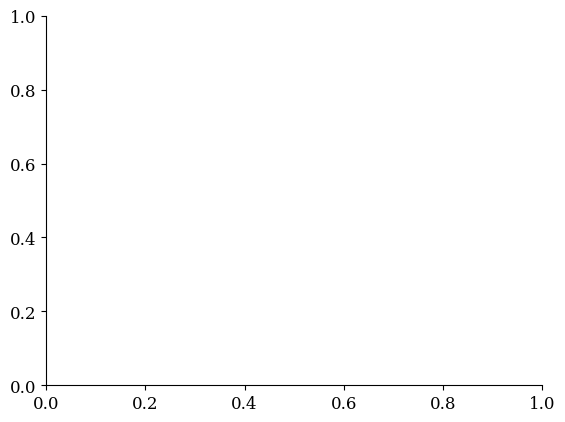

In [20]:
# Initialize new session for not-MIWAE
sess_notmiwae = tf.Session(config=config)
sess_notmiwae.run(tf.global_variables_initializer())

print("Training not-MIWAE...")

W_history, b_history, step_history = [], [], []

losses_notmiwae = train_model(
    sess_notmiwae, train_op_notmiwae,  loss_notmiwae, kl_divergence,"not-MIWAE",
    X_train_masked, S_train, max_iter, batch_size, n_samples
)
print("not-MIWAE training complete!")

import matplotlib.pyplot as plt

plt.figure()
plt.plot(step_history, W_history)
plt.xlabel("Iteration")
plt.ylabel("W_missing")
plt.title("Évolution de W_missing (not-MIWAE)")
plt.grid(True)

plt.figure()
plt.plot(step_history, b_history)
plt.xlabel("Iteration")
plt.ylabel("b_missing")
plt.title("Évolution de b_missing (not-MIWAE)")
plt.grid(True)

plt.show()


In [21]:
def plot_comparison_results():
    """Visualise les résultats du missing model."""

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 1. Accuracy au cours du temps
    axes[0].plot(step_history, accuracy_history, 'b-', linewidth=2)
    axes[0].axhline(y=0.95, color='g', linestyle='--', label='Objectif 95%')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'Missing Model Accuracy ({MISSING_MODEL_TYPE.upper()})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if MISSING_MODEL_TYPE == 'linear' and len(W_history) > 0:
        axes[1].plot(step_history, W_history, 'r-', linewidth=2, label='W appris')
        axes[1].axhline(y=-50, color='r', linestyle='--', alpha=0.5, label='W vrai (-50)')
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('W value')
        axes[1].set_title('Evolution de W')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(step_history, b_history, 'b-', linewidth=2, label='b appris')
        axes[2].axhline(y=0.75, color='b', linestyle='--', alpha=0.5, label='b vrai (0.75)')
        axes[2].set_xlabel('Iteration')
        axes[2].set_ylabel('b value')
        axes[2].set_title('Evolution de b')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'CNN Model\n(pas de paramètres W, b)',
                    ha='center', va='center', fontsize=12,
                    transform=axes[1].transAxes)
        axes[1].axis('off')

        axes[2].text(0.5, 0.5, f'Accuracy finale: {accuracy_history[-1]:.4f}',
                    ha='center', va='center', fontsize=14,
                    transform=axes[2].transAxes)
        axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'missing_model_{MISSING_MODEL_TYPE}.png', dpi=150)
    plt.show()

    print("\n" + "="*60)
    print(f"RÉSUMÉ - Missing Model ({MISSING_MODEL_TYPE.upper()})")
    print("="*60)
    print(f"Accuracy finale: {accuracy_history[-1]:.4f}")
    if MISSING_MODEL_TYPE == 'linear':
        print(f"W appris: {W_history[-1]:.3f} (vrai: -50)")
        print(f"b appris: {b_history[-1]:.3f} (vrai: 0.75)")
    print("="*60)

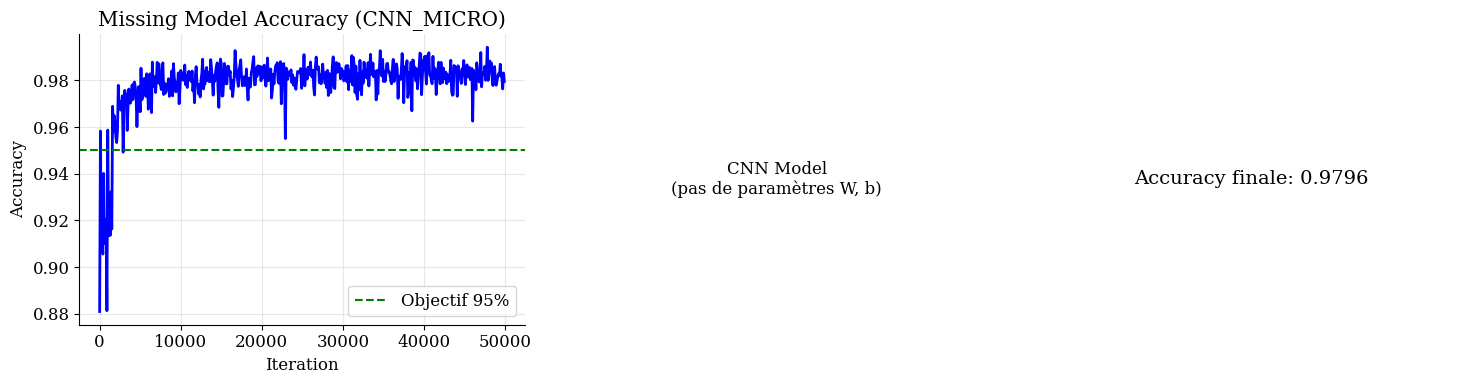


RÉSUMÉ - Missing Model (CNN_MICRO)
Accuracy finale: 0.9796


In [22]:
plot_comparison_results()

#Appeler après l'entraînement :
# plot_comparison_results()


---

## Ordre des cellules dans le notebook

1. Imports et setup
2. Load SVHN Data  
3. Introduce Missing Data
4. Hyperparameters
5. Placeholders (tf.reset_default_graph())
6. Encoder
7. Variational
8. Decoder
9. Observation model
____
10. ★ CELLULE 1 : Configuration (MISSING_MODEL_TYPE)
11. ★ CELLULE 2 : Missing Model (CNN ou linéaire)
_____
12. CELLULE 3 : Log-likelihoods
13. CELLULE 4 : Objectives
14. ★ CELLULE 5 : KL Monitoring
15. CELLULE 6 : Training Setup
16. ★ CELLULE 7 : train_model function
17. Imputation Functions (garde les existantes)
18. Train not-MIWAE
19. Compute imputations
20. Calculate RMSE
21. ★ CELLULE 8 : plot_comparison_results()
22. Visualizations

In [23]:
# %%
def evaluate_missing_model(sess, X_test, S_test, batch_size=100):
    """
    Évalue la qualité du missing model sur le test set.

    Retourne:
    - accuracy: % de prédictions correctes du masque
    - mean_prob_missing: probabilité moyenne prédite pour les pixels manquants
      (devrait être proche de 0 si le modèle apprend bien)
    """
    N = len(X_test)
    accuracies = []
    probs_missing_list = []

    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        x_batch = X_test[start:end]
        s_batch = S_test[start:end]

        acc, prob_miss = sess.run(
            [missing_model_accuracy, mean_prob_for_missing],
            {x_pl: x_batch, s_pl: s_batch, n_pl: 1, is_training: False}
        )

        accuracies.append(acc)
        probs_missing_list.append(prob_miss)

    return np.mean(accuracies), np.mean(probs_missing_list)

# Après l'entraînement, appeler:
# test_accuracy, test_prob_missing = evaluate_missing_model(sess_notmiwae, X_test_masked, S_test)
# print(f"Test Accuracy: {test_accuracy:.4f}")
# print(f"Mean prob for missing pixels: {test_prob_missing:.4f}")

In [24]:
test_accuracy, test_prob_missing = evaluate_missing_model(sess_notmiwae, X_test_masked, S_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Mean prob for missing pixels: {test_prob_missing:.4f}")

Test Accuracy: 0.9691
Mean prob for missing pixels: 0.2278




---

# Partie 2 : Ce qu'on observe avec le CNN (au lieu de W et b)

C'est une excellente question parce que ça change notre façon de penser les résultats.

Avec le modèle **linéaire**, tu avais deux nombres magiques :
- W = -50 : la pente
- b = 0.75 : le threshold

C'est simple. Tes questions étaient : "Est-ce que le modèle retrouve W et b ?"

Avec le **CNN**, tu n'as plus deux nombres. À la place, tu as une **carte spatiale** de 32×32 pixels qui dit pour chaque position de l'image : "Selon moi (le CNN), quelle est la probabilité que ce pixel doive être observé ?"

Voici concrètement ce qu'on observe :

**Image 1 : Les logits bruts du CNN [-5 à +5]**

Imagine que tu regardes une image avec des chiffres blancs sur fond noir. Voici ce qu'on espère voir :

- **Zones blanches (fond)** : Logits très négatifs (ex: -3 à -5). Ça signifie "le CNN pense fortement que ce pixel doit être MANQUANT parce que c'est blanc".

- **Zones noires (chiffres)** : Logits proches de 0 ou positifs (ex: -1 à +2). Ça signifie "le CNN pense que ce pixel a une chance raisonnable d'être OBSERVÉ même s'il est noir".

- **Bordures (transitions noir→blanc)** : Logits intermédiaires (ex: -2 à -0.5). C'est l'intéressant : le CNN apprend que "aux arêtes des chiffres, même si c'est un peu blanc, c'est important".

**Image 2 : Les probabilités prédites par le CNN [0 à 1]**

C'est juste la version "douce" des logits. Après sigmoid, ça devient des probabilités.

- Bleu foncé (0.1) = "je pense que ce pixel a 10% de chance d'être observé"
- Rose (0.5) = "je suis indécis"
- Vert brillant (0.9) = "je suis sûr que ce pixel doit être observé"

**Image 3 : La différence avec le ground truth**

C'est la plus informative. C'est la valeur absolue entre "ce que le CNN prédit" et "ce qui s'est vraiment passé".

- **Bleu clair** = Le CNN a raison
- **Rouge foncé** = Le CNN se trompe

Si tu vois du rouge foncé partout, c'est mauvais. Si tu vois surtout du bleu clair, c'est que le CNN a compris le pattern.

---

## Voici ce qu'on ESPÈRE voir si le CNN fonctionne bien

Imagine l'image du chiffre "8" avec clipping blanc :

**Le vrai mask** : Tous les pixels blancs sont manquants (=0), tous les noirs sont observés (=1)

**Le CNN apprend ceci** : "Hmm, j'observe que les pixels blancs tendent à être manquants, MAIS je remarque aussi que les pixels blancs aux arêtes du chiffre (où il y a du contraste local) sont encore observés. Donc je vais prédire des probabilités plus altes là où il y a du gradient."

**Le résultat** :
- Zones blanches uniformes : CNN prédit P ≈ 0.05 (fortement manquant) ✓
- Arêtes noires→blanches : CNN prédit P ≈ 0.7 (indécis mais penchant observé) ✓
- Zones noires : CNN prédit P ≈ 0.95 (fortement observé) ✓

**La différence avec ground truth** : Petite ! Surtout rouge clair. Ça signifie "le CNN a compris la structure".

---

## Ce qu'on craint de voir si le CNN échoue

Si le CNN **ne capture pas** la structure spatiale :

- Partout, le CNN prédit P ≈ 0.5 (complètement indécis)
- Ou pire, les prédictions sont **opposées** au ground truth (CNN prédit observé quand manquant)
- Ou hyper-bruyant : chaque pixel a une prédiction différente sans pattern cohérent

---

# Partie 3 : Comment comparer CNN vs Linéaire

La comparaison se fait sur **trois axes** :

## Axe 1 : Accuracy du missing model

Voici la question : "À quel point chaque modèle comprend le processus de clipping ?"

Accuracy = (% de pixels où le modèle prédit correctement observé/manquant)

___

In [25]:
# Essayer de unpacker losses_notmiwae
try:
    losses_notmiwae, kl_notmiwae = losses_notmiwae
    print(f"✓ Succès ! KL values récupérées. Longueur: {len(kl_notmiwae)}")
    print(f"Premiers KL values: {kl_notmiwae[:5]}")
except ValueError:
    print("✗ losses_notmiwae n'est pas un tuple (la fonction retourne probablement juste losses)")
except TypeError as e:
    print(f"✗ Erreur: {e}")

✓ Succès ! KL values récupérées. Longueur: 50000
Premiers KL values: [np.float32(0.071697295), np.float32(0.36087742), np.float32(1.0461154), np.float32(0.19569713), np.float32(0.081506684)]


In [26]:
# Impute with not-MIWAE
print("\nComputing not-MIWAE imputations...")
imputations_notmiwae = impute_notmiwae(sess_notmiwae, X_test_masked, S_test, L=1000)


Computing not-MIWAE imputations...
not-MIWAE imputation: 0/2000
not-MIWAE imputation: 200/2000
not-MIWAE imputation: 400/2000
not-MIWAE imputation: 600/2000
not-MIWAE imputation: 800/2000
not-MIWAE imputation: 1000/2000
not-MIWAE imputation: 1200/2000
not-MIWAE imputation: 1400/2000
not-MIWAE imputation: 1600/2000
not-MIWAE imputation: 1800/2000


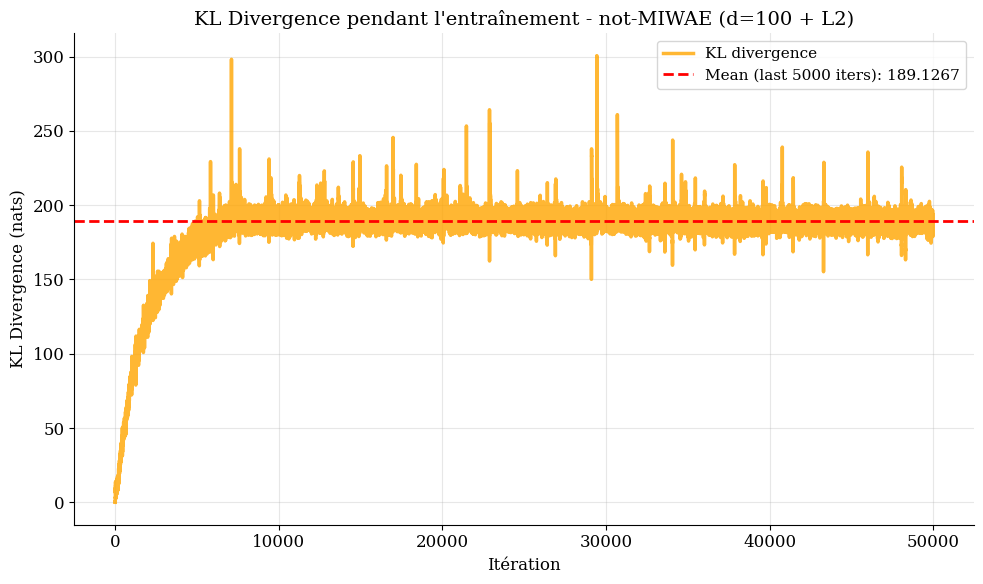


KL DIVERGENCE ANALYSIS - not-MIWAE
KL initial (iter 0-1000):     42.4766 nats
KL final (iter -5000):        189.1267 nats
KL min:                       0.0102
KL max:                       300.6078
Progression (final - initial): 146.6501 nats

DIAGNOSTIC:
✓  EXCELLENT: KL très élevé, modèle utilise l'espace latent de manière très active


In [27]:
# Visualiser l'évolution du KL divergence pendant l'entraînement (not-MIWAE uniquement)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

iterations = np.arange(len(kl_notmiwae))
ax.plot(iterations, kl_notmiwae, linewidth=2.5, color='orange', alpha=0.8, label='KL divergence')

ax.set_xlabel('Itération', fontsize=12)
ax.set_ylabel('KL Divergence (nats)', fontsize=12)
ax.set_title('KL Divergence pendant l\'entraînement - not-MIWAE (d=100 + L2)', fontsize=14)
ax.grid(True, alpha=0.3)

# Ajouter une ligne horizontale pour la moyenne des dernières 5000 itérations
mean_kl_final = np.mean(kl_notmiwae[-5000:])
ax.axhline(y=mean_kl_final, color='red', linestyle='--', linewidth=2, label=f'Mean (last 5000 iters): {mean_kl_final:.4f}')

ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kl_evolution_notmiwae.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques résumées
print("\n" + "="*70)
print("KL DIVERGENCE ANALYSIS - not-MIWAE")
print("="*70)
print(f"KL initial (iter 0-1000):     {np.mean(kl_notmiwae[:1000]):.4f} nats")
print(f"KL final (iter -5000):        {np.mean(kl_notmiwae[-5000:]):.4f} nats")
print(f"KL min:                       {np.min(kl_notmiwae):.4f}")
print(f"KL max:                       {np.max(kl_notmiwae):.4f}")
print(f"Progression (final - initial): {np.mean(kl_notmiwae[-5000:]) - np.mean(kl_notmiwae[:1000]):.4f} nats")
print("="*70)

# Diagnostic
print("\nDIAGNOSTIC:")
kl_final_mean = np.mean(kl_notmiwae[-5000:])
if kl_final_mean < 0.1:
    print("⚠️  POSTERIOR COLLAPSE DÉTECTÉ: KL très bas, modèle ignore l'espace latent")
elif kl_final_mean > 50.0:
    print("✓  EXCELLENT: KL très élevé, modèle utilise l'espace latent de manière très active")
elif kl_final_mean > 10.0:
    print("✓  BON: KL élevé, modèle utilise bien l'espace latent")
elif kl_final_mean > 2.0:
    print("≈  MODÉRÉ: Utilisation modérée de l'espace latent")
else:
    print("⚠️  BAS: KL très bas, risque de sous-utilisation du latent")

In [28]:
# Calculate not-MIWAE RMSE
rmse_notmiwae = np.sqrt(
    np.sum((X_test - imputations_notmiwae) ** 2 * (1 - S_test)) / np.sum(1 - S_test)
)
print(f"not-MIWAE Imputation RMSE: {rmse_notmiwae:.5f}")

not-MIWAE Imputation RMSE: 0.07597


## 11. Results and Visualization

In [29]:
# Summary of results
print("\n" + "="*50)
print("RESULTS SUMMARY")
print("="*50)
#print(f"Constant Imputation RMSE: {rmse_constant:.5f}")
#print(f"MIWAE Imputation RMSE:    {rmse_miwae:.5f}")
print(f"not-MIWAE Imputation RMSE: {rmse_notmiwae:.5f}")
print("="*50)


RESULTS SUMMARY
not-MIWAE Imputation RMSE: 0.07597


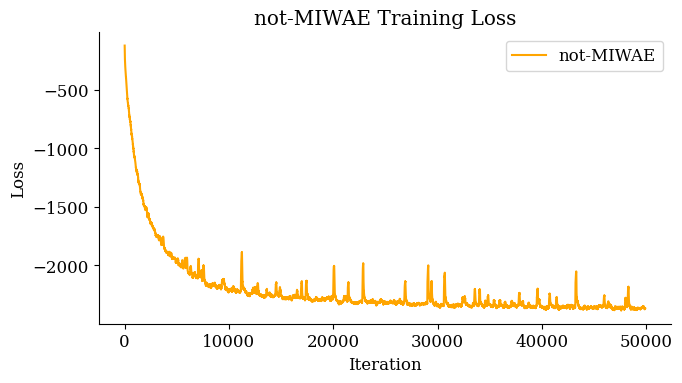

In [30]:
## D=100 not miwae

# Smooth loss for visualization
window = 100
losses_notmiwae_smooth = np.convolve(losses_notmiwae, np.ones(window)/window, mode='valid')

plt.figure(figsize=(7, 4))
plt.plot(losses_notmiwae_smooth, label='not-MIWAE', color='orange')

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('not-MIWAE Training Loss')
plt.legend()
plt.tight_layout()
plt.show()


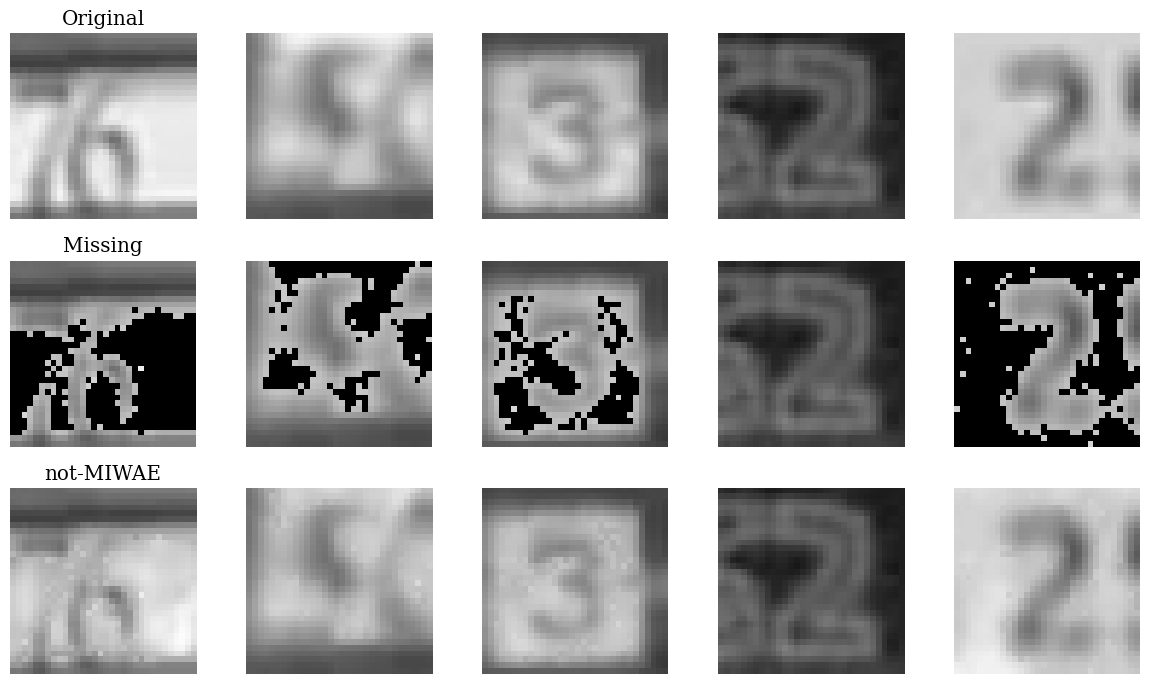

In [31]:
## D=100 NOT MIWAE

# Visualize imputations
n_examples = 5
fig, axes = plt.subplots(3, n_examples, figsize=(12, 7))

for i in range(n_examples):
    idx = i * 50  # Spread out examples

    # Original
    axes[0, i].imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Original' if i == 0 else '')
    axes[0, i].axis('off')

    # With missing
    axes[1, i].imshow(X_test_masked[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Missing' if i == 0 else '')
    axes[1, i].axis('off')

    # not-MIWAE imputation
    axes[2, i].imshow(imputations_notmiwae[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
    axes[2, i].set_title('not-MIWAE' if i == 0 else '')
    axes[2, i].axis('off')

plt.tight_layout()
plt.savefig('svhn_imputations_notmiwae.png', dpi=150, bbox_inches='tight')
plt.show()


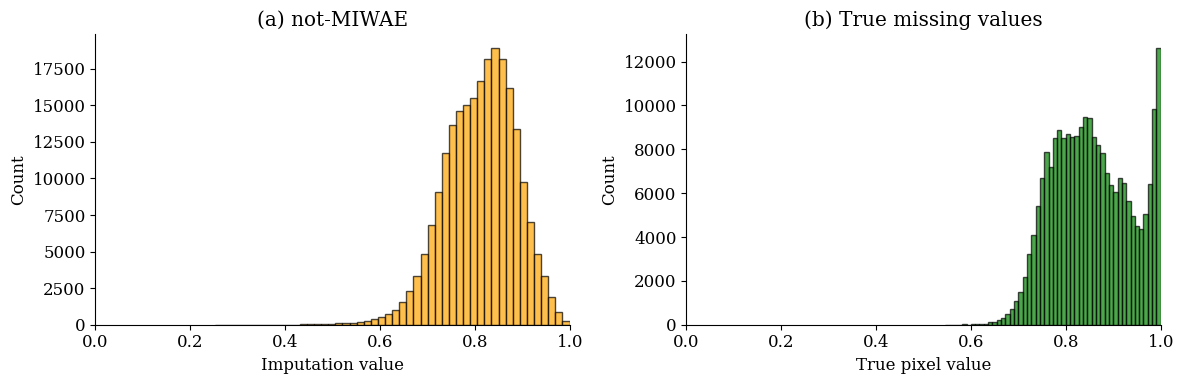

In [32]:
## NOT MIWAE. D=100
# Histograms of imputed values (not-MIWAE only)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Get only the imputed (missing) values
missing_mask = (1 - S_test).astype(bool)

notmiwae_imputed_vals = imputations_notmiwae[missing_mask]
true_missing_vals = X_test[missing_mask]

# not-MIWAE histogram
axes[0].hist(notmiwae_imputed_vals, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_xlabel('Imputation value')
axes[0].set_ylabel('Count')
axes[0].set_title('(a) not-MIWAE')
axes[0].set_xlim([0, 1])

# True missing values histogram
axes[1].hist(true_missing_vals, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('True pixel value')
axes[1].set_ylabel('Count')
axes[1].set_title('(b) True missing values')
axes[1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('svhn_histograms_notmiwae.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# Print statistics about imputations
print("\nImputation Statistics:")
print(f"True missing values - Mean: {np.mean(true_missing_vals):.3f}, Std: {np.std(true_missing_vals):.3f}")
#print(f"MIWAE imputations   - Mean: {np.mean(miwae_imputed_vals):.3f}, Std: {np.std(miwae_imputed_vals):.3f}")
print(f"not-MIWAE imputations - Mean: {np.mean(notmiwae_imputed_vals):.3f}, Std: {np.std(notmiwae_imputed_vals):.3f}")

# Percentage above clipping threshold
print(f"\nPercentage above clipping threshold (0.75):")
print(f"True missing values:  {100*np.mean(true_missing_vals > 0.75):.1f}%")
#print(f"MIWAE imputations:    {100*np.mean(miwae_imputed_vals > 0.75):.1f}%")
print(f"not-MIWAE imputations: {100*np.mean(notmiwae_imputed_vals > 0.75):.1f}%")


Imputation Statistics:
True missing values - Mean: 0.855, Std: 0.083
not-MIWAE imputations - Mean: 0.812, Std: 0.074

Percentage above clipping threshold (0.75):
True missing values:  90.3%
not-MIWAE imputations: 79.5%


## 12. Close Sessions

In [34]:
#sess_miwae.close()
sess_notmiwae.close()
print("Sessions closed.")

Sessions closed.
